# Sextic Ornstein--Uhlenbeck with white noise --- cubic + quintic nonlinearity at two loops

**Showcases:** a higher-order scalar nonlinearity --- a potential with **two** interaction vertices --- driven by white Gaussian noise. On top of the cubic restoring force $-\varepsilon x^3$ (a quartic potential term, i.e.\ a 4-point vertex) the drift adds a quintic $-\gamma x^5$ (a sextic potential term, i.e.\ a 6-point vertex). Both vertices feed the loop expansion, so this is the natural next step beyond the quartic baseline. Single physical field, white noise, single well at $\mu>0$; run here to **two loops**.

$$\dot x = -\mu\,x - \varepsilon\,x^3 - \gamma\,x^5 + \xi,\qquad \langle\xi(t)\xi(t')\rangle = 2D\,\delta(t-t'),\qquad U(x)=\tfrac{\mu}{2}x^2+\tfrac{\varepsilon}{4}x^4+\tfrac{\gamma}{6}x^6.$$

## 0. Setup

In [1]:
%matplotlib inline
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt
# depth-robust repo root: walk up until the 'pipeline' package is found
_root = os.path.abspath('')
while _root != os.path.dirname(_root) and not os.path.isdir(os.path.join(_root, 'pipeline')):
    _root = os.path.dirname(_root)
sys.path.insert(0, _root)
sys.path.insert(0, os.path.join(_root, 'notebooks'))
os.chdir(os.path.join(_root, 'notebooks'))  # cwd=notebooks/ for models/ data paths
import daedalus as dd

## 1. The model

`dd.describe_model` prints the structure straight from the theory file. A single physical field $x$; the governing equation carries both the cubic and the quintic restoring terms. With $\mu,\varepsilon,\gamma>0$ the Boltzmann potential $U(x)$ is bounded below and the mean-field saddle is $x^*=0$ (single well).

In [2]:
THEORY = 'ou_sextic'
model, mod = dd.load_theory(THEORY)
dd.describe_model(model, mod)
print('\nphysical fields:', dd.field_names(model))

────────────────────────────────────────────────────────────────────────
  OU Sextic
────────────────────────────────────────────────────────────────────────
Domain         : temporal ODE (time-only)
Fields         : x — variable
Response fields: xt
Parameters     :
    mu = 1.0  (positive)
    eps = 0.05  (positive)
    D = 1.0  (positive)
    gamma = 0.05  (positive)
Mean-field saddle (solved by the pipeline): xstar
Governing eqn  : (Dt+mu)*x[i] = -eps*x[i]^3 - gamma*x[i]^5
Suggested run  : k=2, max_ell=0

physical fields: ['dx']


## 2. Contributing diagrams

Before evaluating anything, it helps to *see* what the pipeline sums. `dd.plot_prediagrams` draws the **contributing prediagrams** — the directed MSR-JD topologies that survive this theory's vertex/source filter — grouped by topology family, in the Buice/Ocker convention: **time flows right → left**, with noise **sources on the right** ($i, ii, \dots$), **interaction vertices in the middle** ($a, b, c, \dots$), and **external legs on the left** ($1, 2, \dots$). Each propagator carries a mid-edge arrowhead giving its direction; **propagators are named by their endpoints** (e.g. $a\to b$) rather than numbered, so the figure stays uncluttered (the two halves of a bubble are then just $a\to b$ and $b\to a$).

`dd.prediagram_mappings` prints the per-diagram **label map** — how those generic labels specialise to this theory's field types: source $i \to K^{(2)}$, vertex $a \to$ the interaction monomial, propagator $a\to b \to G[\phi \leftarrow \tilde\phi]$, external leg $1 \to$ the field.

Shown here at $\ell \le 1$ (tree + one loop) for legibility. The §3 run goes to **two loops**, where the set grows to 73 diagrams --- including the one degree-6 topology where the bare 6-point $\gamma$ vertex enters directly; call `dd.plot_prediagrams(model, 2, 2)` to enumerate them all.

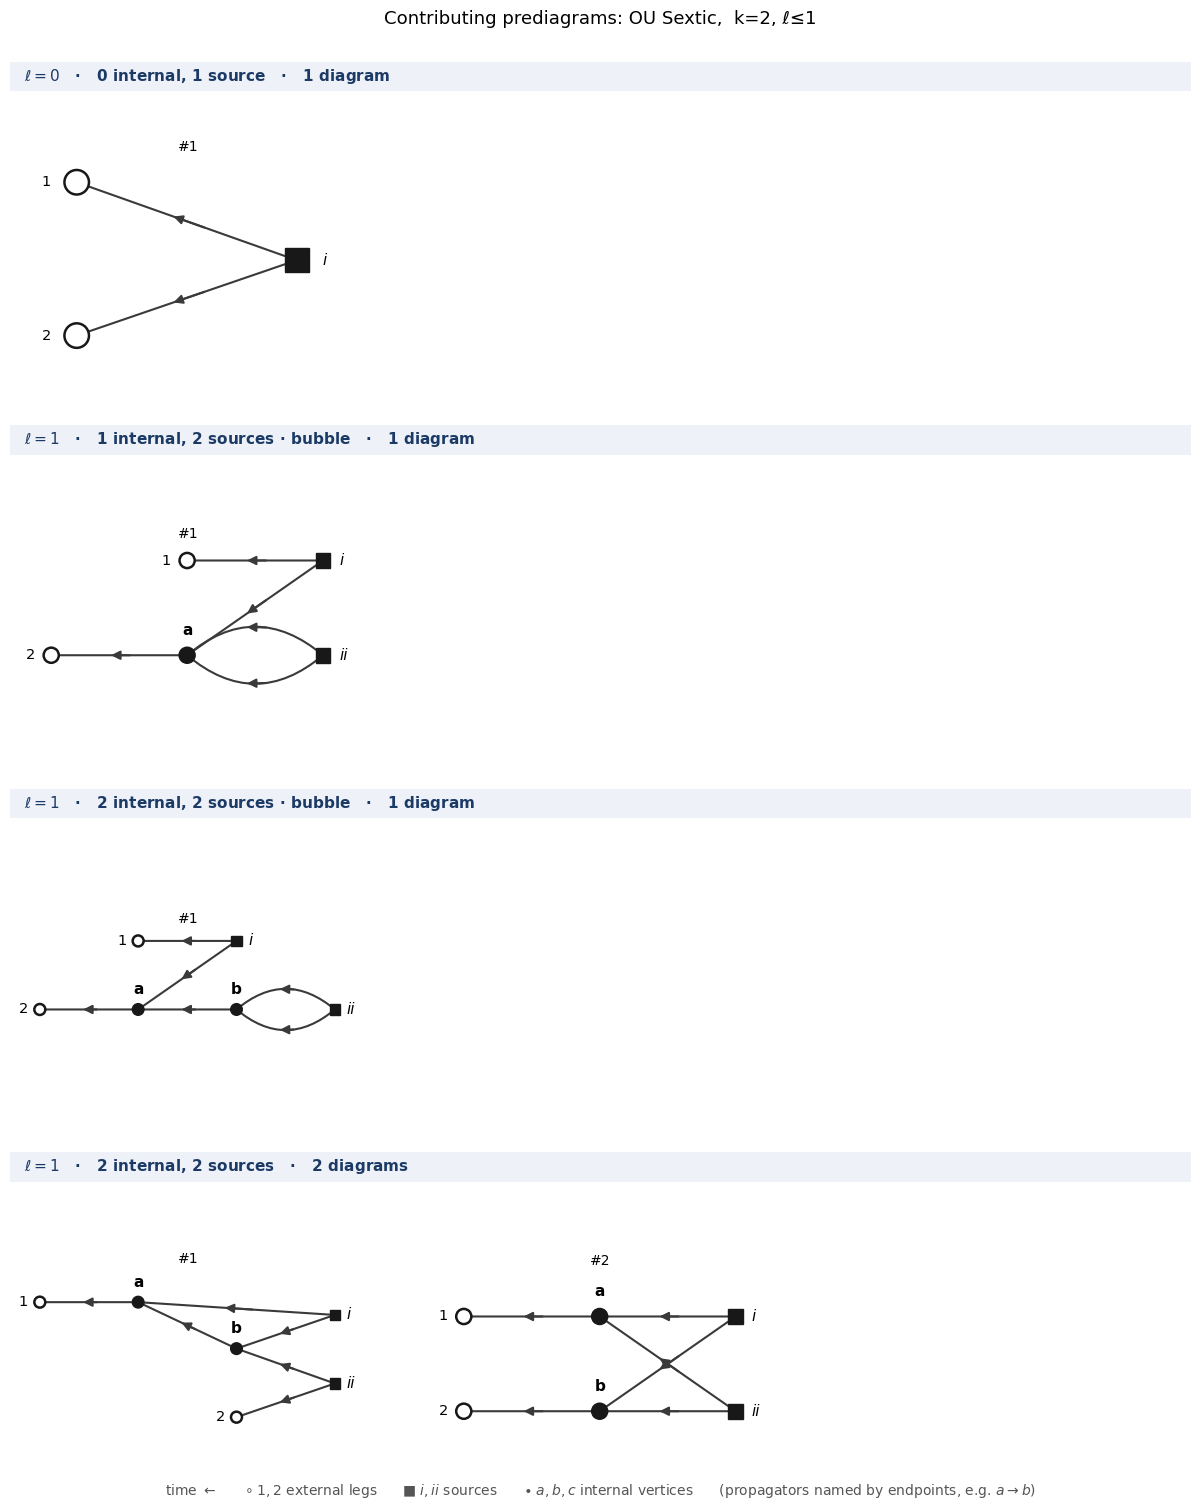

In [3]:
# Diagram topologies summed for C_xx(τ), grouped by family (tree + 1-loop here).
dd.plot_prediagrams(model, k=2, max_ell=1)
plt.show()

In [4]:
# The label map: how each generic prediagram label specialises to this theory.
_ = dd.prediagram_mappings(model, k=2, max_ell=1)

════════════════════════════════════════════════════════════════════════
 OU Sextic — prediagram → typed-diagram label maps  (k=2, ℓ≤1)
════════════════════════════════════════════════════════════════════════

ℓ=0 · 0 internal, 1 source · #1   (1 typing)
  ── typing 1 ──
     source i    → K^(2) ⟨xt xt⟩
     propagator i→1     → G[dx ← xt]
     propagator i→2     → G[dx ← xt]
     external legs → 1=dx, 2=dx

ℓ=1 · 1 internal, 2 sources · bubble · #1   (1 typing)
  ── typing 1 ──
     source i    → K^(2) ⟨xt xt⟩
     source ii   → K^(2) ⟨xt xt⟩
     vertex a    → coeff 10*gamma*xstar1^2 + eps   resp⟨xt⟩ phys⟨dx dx dx⟩
     propagator a→2     → G[dx ← xt]
     propagator ii→a₁   → G[dx ← xt]
     propagator ii→a₂   → G[dx ← xt]
     propagator i→1     → G[dx ← xt]
     propagator i→a     → G[dx ← xt]
     external legs → 1=dx, 2=dx

ℓ=1 · 2 internal, 2 sources · bubble · #1   (1 typing)
  ── typing 1 ──
     source i    → K^(2) ⟨xt xt⟩
     source ii   → K^(2) ⟨xt xt⟩
     vertex a    → 

## 3. The pipeline → theoretical cumulants

One `dd.run` drives the whole MSR-JD chain (enumerate diagrams → propagator → mean-field saddle → loop integrals → cumulant). Because the action now has two vertices --- the cubic $\varepsilon x^3$ (4-point) and the quintic $\gamma x^5$ (6-point) --- the 2-loop diagram set is richer than the quartic case, yet still cheap (one white-noise field). The plot is the **theory only**; the simulation is added in §4.

In [5]:
cfg = dd.Config(
    k=2, max_ell=2,                          # C_xx(τ), tree + 1-loop + 2-loop
    external_fields=[('dx', 1), ('dx', 1)],  # physical-field autocorrelator
    parameters={'mu': 1.0, 'eps': 0.01, 'gamma': 0.002, 'D': 1.0},  # mildly perturbative
    tau_max=8.0, tau_step=0.5,
    parallel=False,                          # serial (no fork in a notebook)
)

theory : 'OU Sextic'
k      : 2    max_ell : 2
fields : ['dx']   spatial_dim : 0


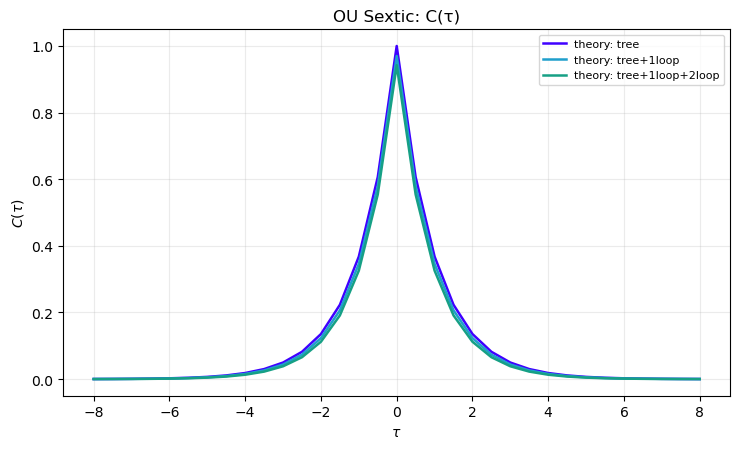

In [6]:
res = dd.run(model, cfg, mod)
print(dd.summary(res))
dd.plot_cumulant(res, cfg, model)   # theory only
plt.show()

## 4. Independent simulation

A direct Euler--Maruyama integration of the sextic SDE --- written from scratch, no reference to the diagrammatics. The drift carries both the $-\varepsilon x^3$ and $-\gamma x^5$ terms; we estimate the connected $C_{xx}(\tau)$ and overlay it on the pipeline curve.

sim took 8.5s  (3 runs × T=2e+05)
C_xx(0):  tree = 1.0000   tree+loops = 0.9424   sim = 0.9501 ± 0.0026


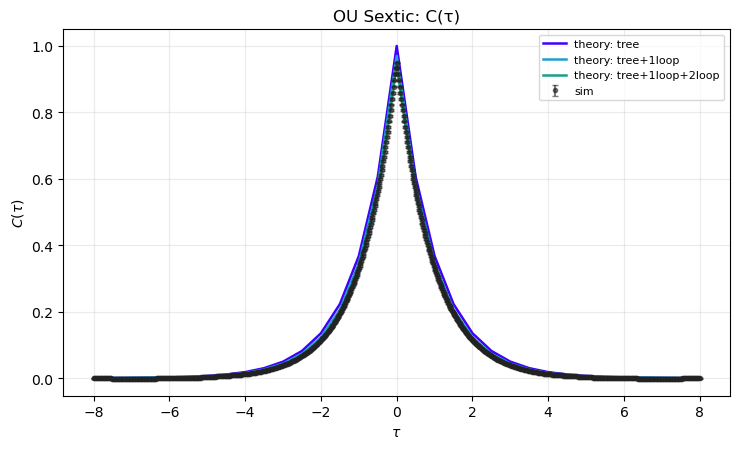

In [7]:
# Independent SDE simulation (Euler–Maruyama, white Gaussian noise) — NOT the pipeline.
from models.ou_langevin_sim_numba import sim_ou_sextic_numba
from models.cumulant_estimator import estimate_kpoint_slices
fp = res['_resolved']['parameters']          # same physics as the theory run
# Cast to plain Python floats — under the Sage kernel the resolved params are
# Sage ring elements, which numba's njit cannot type.
mu = float(fp['mu']); eps = float(fp['eps'])
gamma = float(fp['gamma']); D = float(fp['D'])

# Discretization.  dt_sim ≪ relaxation time 1/mu; bin FINELY (dt_bin ≪ 1/mu)
# so the bin-averaged variance is effectively the instantaneous C_xx(0).
dt_sim, dt_bin = float(0.01), float(0.02)
T_sim          = float(2.0e5)              # ~1-min run for clean error bars
N_RUNS         = int(3)
tau_max        = float(cfg.tau_max)
n_steps        = int(T_sim / dt_sim)
bin_size_steps = int(max(round(float(dt_bin / dt_sim)), 1))
dt_bin_eff     = float(bin_size_steps * dt_sim)
n_bins         = int(n_steps // bin_size_steps)
max_lag_bins   = int(tau_max / dt_bin_eff)
x_init         = float(0.0)

# k-aware estimator (here k=2 → a single autocorrelation slice).
k         = int(res['_resolved']['k'])
base      = list(cfg.kpoint_base_lags) if cfg.kpoint_base_lags else [0.0]*(k-1)
base_bins = [int(round(b / dt_bin_eff)) for b in base]
pop_indices = [0]*k
field_types = ['dv']*k

_ = sim_ou_sextic_numba(int(1000), dt_sim, mu, eps, gamma, D, x_init,
                        bin_size_steps, int(100), int(0))    # JIT warmup
rng_base = int(np.random.SeedSequence().generate_state(1)[0]) % (2**31)
C_runs = []
t0 = time.perf_counter()
for r in range(N_RUNS):
    x_bins = sim_ou_sextic_numba(n_steps, dt_sim, mu, eps, gamma, D, x_init,
                                 bin_size_steps, n_bins, int(rng_base + r))
    tau_sim, Cj = estimate_kpoint_slices(
        dt_bin_eff, pop_indices, field_types, base_bins,
        int(max_lag_bins), voltage_bins=x_bins)              # Cj: (k-1, n_tau)
    C_runs.append(np.asarray(Cj).real)
C_arr = np.array(C_runs)
C_sim = C_arr.mean(axis=0)
C_err = C_arr.std(axis=0, ddof=1) / np.sqrt(N_RUNS)
sim   = {'tau': tau_sim, 'C': C_sim, 'C_err': C_err}
print('sim took %.1fs  (%d runs × T=%.0g)' % (time.perf_counter() - t0, N_RUNS, T_sim))

i0 = int(np.argmin(np.abs(np.asarray(res['tau_grid']))))
js = int(np.argmin(np.abs(tau_sim)))
C0_tree = np.real(res['C_tau_by_ell'][0])[i0]
C0_loop = np.real(res['C_tau'])[i0]
print('C_xx(0):  tree = %.4f   tree+loops = %.4f   sim = %.4f ± %.4f'
      % (C0_tree, C0_loop, C_sim[0][js], C_err[0][js]))
dd.plot_cumulant(res, cfg, model, sim=sim)
plt.show()

## Summary

The equal-time variance $C_{xx}(0)$ sits just below the linear value $D/\mu=1$: both the cubic and the quintic restoring terms stiffen the potential and suppress fluctuations, and the 2-loop self-energy --- now fed by a 4-point *and* a 6-point vertex --- captures that shift, moving the theory from the tree estimate toward the direct simulation. This is the same machinery as the quartic baseline, with one extra (higher-degree) vertex; raising $\gamma$ (or lowering $\mu$) strengthens the quintic contribution and widens the tree-vs-loop gap.